In [2]:
import os
import pandas as pd
import numpy as np 
import seaborn as sns
from tqdm import tqdm
import pickle

from pydub import AudioSegment
from IPython.display import Audio

import librosa
import librosa.display
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, accuracy_score
import itertools

import warnings
warnings.filterwarnings("ignore")

In [3]:
ds_train = pd.read_csv('./data/chunks_specie_sample_train.csv')
ds_test = pd.read_csv('./data/chunks_specie_sample_test.csv')
ds_val = pd.read_csv('./data/chunks_specie_sample_val.csv')
ds_train = ds_train[['audio_path', 'label']]
ds_test = ds_test[['audio_path', 'label']]
ds_val = ds_val[['audio_path', 'label']]
print(ds_train.shape)
print(ds_test.shape)
print(ds_val.shape)
ds_train.sample(5)

(22066, 2)
(4398, 2)
(10168, 2)


,audio_path,label
514,chunks/72442_chunk1.mp3,Troglodytes aedon
14369,chunks/28617_chunk12.mp3,Troglodytes aedon
3789,chunks/141699_chunk3.mp3,Microcerculus marginatus
4474,chunks/211509_chunk12.mp3,Pheugopedius genibarbis
10349,chunks/674076_chunk23.mp3,Henicorhina leucophrys


In [4]:
#ds_train = ds_train[ds_train['audio_path'] != 'chunks/337985_chunk40.mp3']
#ds_train.reset_index(drop=True, inplace=True)

# guardar los datasets
#ds_train.to_csv('/Users/camcortes/Documents/birds-sounds/data/chunks_specie_sample_train.csv', index=False)

In [5]:
# label encoder
le = LabelEncoder()
ds_train['label'] = le.fit_transform(ds_train['label'])
ds_test['label'] = le.transform(ds_test['label'])
ds_val['label'] = le.transform(ds_val['label'])

In [6]:
etiquetas = ds_train['label']
clases, conteo_clases = np.unique(etiquetas, return_counts=True)
weight = dict(zip(clases, np.max(conteo_clases) / conteo_clases))

In [7]:
X = ds_train['audio_path']
y = ds_train['label']

X_test = ds_test['audio_path']
y_test = ds_test['label']

X_val = ds_val['audio_path']
y_val = ds_val['label']

In [8]:
num_clases = y.nunique()
print(num_clases)

37


In [9]:
#getting mfcc features for all the data points in test and train

def get_mfcc(path):
    """
    Extracts MFCC (Mel-frequency cepstral coefficients) features from an audio file.
    
    Parameters:
    path (str): The file path to the audio file.
    
    Returns:
    numpy.ndarray: A 2D array where each row corresponds to the MFCC features of a frame.
    """
    y, sr = librosa.load(path, sr=None, mono=True)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=10000)
    mfccs = librosa.feature.mfcc(S=librosa.power_to_db(S), n_mfcc=40)
    return mfccs.T

In [10]:
def process_audio_files(X, y):
    """
    Processes a list of audio file paths to extract MFCC features and resize them.
    
    Args:
        X (pd.Series): A pandas Series containing paths to audio files.
        y (pd.Series): A pandas Series containing labels corresponding to the audio files.
        
    Returns:
        tuple: A tuple containing:
            - X_processed (np.ndarray): A numpy array of processed MFCC features with shape (num_files, 65, 40).
            - y_processed (np.ndarray): A numpy array of labels corresponding to the audio files.
    """
    temp = []
    label = []
    
    for i in tqdm(range(len(X))):
        audio_path = X.iloc[i]
        mfcc = get_mfcc(audio_path)
        mfcc = np.resize(mfcc, (65, 40,))
        temp.append(mfcc)
        label.append(y.iloc[i])
        
    X_processed = np.asarray(temp)
    y_processed = np.asarray(label)
    
    return X_processed, y_processed

In [11]:
#%%time
X_processed, y = process_audio_files(X, y)
X_test_processed, y_test = process_audio_files(X_test, y_test)
X_val_processed, y_val = process_audio_files(X_val, y_val)

  0%|          | 0/22066 [00:00<?, ?it/s]

100%|██████████| 10168/10168 [02:02<00:00, 82.75it/s]


In [12]:
with open('X_processed.pkl', 'wb') as f:
    pickle.dump(X_processed, f)
    
with open('y_train.pkl', 'wb') as f:
    pickle.dump(y, f)

with open('X_test_processed.pkl', 'wb') as f:
    pickle.dump(X_test_processed, f)
    
with open('y_test.pkl', 'wb') as f:
    pickle.dump(y_test, f)
    
with open('X_val_processed.pkl', 'wb') as f:
    pickle.dump(X_val_processed, f)
    
with open('y_val.pkl', 'wb') as f:
    pickle.dump(y_val, f)

In [13]:
with open('X_processed.pkl', 'rb') as f:
    X_processed = pickle.load(f)

with open('y_train.pkl', 'rb') as f:
    y = pickle.load(f)

with open('X_test_processed.pkl', 'rb') as f:
    X_test_processed = pickle.load(f)
    
with open('y_test.pkl', 'rb') as f:
    y_test = pickle.load(f)

with open('X_val_processed.pkl', 'rb') as f:
    X_val_processed = pickle.load(f)
    
with open('y_val.pkl', 'rb') as f:
    y_val = pickle.load(f)

In [14]:
print(f'El conjunto de entrenamiento tiene la forma {X_processed.shape}')
print(f'Los labels del conjunto de entrenamiento tiene la forma {y.shape}')

El conjunto de entrenamiento tiene la forma (22066, 65, 40)
Los labels del conjunto de entrenamiento tiene la forma (22066,)


## **Modelo**

In [15]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model
import keras.backend as K

tf.keras.backend.clear_session()

In [16]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


In [17]:
print(tf.config.list_physical_devices('GPU'))

[]


In [18]:
# Capa de entrada
input_layer = layers.Input(shape=(65, 40), name='input_layer')

# Bloque convolucional 1
x = layers.Conv1D(filters=64, kernel_size=6, padding='same')(input_layer)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Conv1D(filters=128, kernel_size=9, padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling1D(pool_size=2)(x)
x = layers.Dropout(0.2)(x)

# Bloque convolucional 2
x = layers.Conv1D(filters=128, kernel_size=9, padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Conv1D(filters=256, kernel_size=12, padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling1D(pool_size=2)(x)
x = layers.Dropout(0.2)(x)

# Bloque convolucional 3
x = layers.Conv1D(filters=256, kernel_size=12, padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Conv1D(filters=256, kernel_size=15, padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling1D(pool_size=2)(x)
x = layers.Dropout(0.2)(x)

# Capas LSTM bidireccionales
x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
x = layers.Bidirectional(layers.LSTM(64, return_sequences=False))(x)
x = layers.Dropout(0.5)(x)

# Capas densas
x = layers.Dense(256, activation='relu', kernel_regularizer='l2')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu', kernel_regularizer='l2')(x)
x = layers.Dropout(0.5)(x)

# Capa de salida
output_layer = layers.Dense(num_clases, activation='softmax', name='output_layer')(x)

# Creación del modelo
model = Model(inputs=input_layer, outputs=output_layer)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 65, 40)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 65, 64)         │        15,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 65, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 65, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 65, 128)        │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 65, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 65, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 32, 128)        │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 32, 256)        │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 32, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 16, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 16, 256)        │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 16, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 16, 256)        │       983,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 256)        │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 3,033,957 (11.57 MB)

 Trainable params: 3,031,781 (11.57 MB)

 Non-trainable params: 2,176 (8.50 KB)

In [19]:
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    'model_weights_mfcc.keras',  
    monitor='val_loss',
    mode='min',
    verbose=1,
    save_weights_only=False,  # guardar solo los pesos
    save_best_only=True,     # guardar solo el mejor modelo
)

# Callback para TensorBoard
tensorboard_cb = tf.keras.callbacks.TensorBoard(
    log_dir='logs',
    histogram_freq=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.1, 
    patience=15, 
    min_lr=0.00001)

# Callback para EarlyStopping
early_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=50,
    mode='min'
)

callbacks = [checkpoint_cb, tensorboard_cb, early_callback, reduce_lr]

In [20]:
#model.load_weights('model_weights_mfcc-v3.weights.h5')

# Paso 3: Compilar el modelo (opcional)
#model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [21]:
#compile
ls = tf.keras.losses.SparseCategoricalCrossentropy()
adam = tf.keras.optimizers.Adam()
model.compile(adam, ls, metrics=['accuracy'])

history = model.fit(X_processed, y, 
                    validation_data=(X_val_processed, y_val),
                    callbacks=callbacks,
                    epochs=1000,
                    batch_size=32,
                    class_weight=weight)

Epoch 1/1000
690/690 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.0330 - loss: 31.1037
Epoch 1: val_loss improved from inf to 5.24217, saving model to model_weights_mfcc.keras
690/690 ━━━━━━━━━━━━━━━━━━━━ 77s 106ms/step - accuracy: 0.0330 - loss: 31.1026 - val_accuracy: 0.0653 - val_loss: 5.2422 - learning_rate: 0.0010
Epoch 2/1000
690/690 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.0452 - loss: 28.6322
Epoch 2: val_loss improved from 5.24217 to 4.46704, saving model to model_weights_mfcc.keras
690/690 ━━━━━━━━━━━━━━━━━━━━ 80s 116ms/step - accuracy: 0.0452 - loss: 28.6321 - val_accuracy: 0.0459 - val_loss: 4.4670 - learning_rate: 0.0010
Epoch 3/1000
690/690 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.0396 - loss: 27.8639
Epoch 3: val_loss improved from 4.46704 to 4.06183, saving model to model_weights_mfcc.keras
690/690 ━━━━━━━━━━━━━━━━━━━━ 80s 116ms/step - accuracy: 0.0396 - loss: 27.8632 - val_accuracy: 0.0301 - val_loss: 4.0618 - learning_rate: 0.0010
Epoch 4/1000
690/6

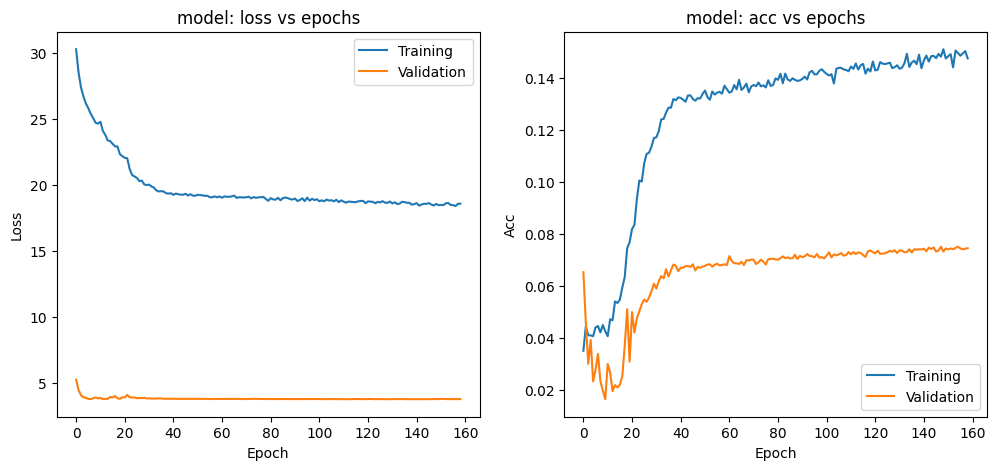

In [22]:
fig = plt.figure(figsize=(12, 5))
fig.add_subplot(121)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model: loss vs epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')

fig.add_subplot(122)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model: acc vs epochs')
plt.ylabel('Acc')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()

## **Predicción**

In [23]:
#carga el modelo model_weights_mfcc
model = tf.keras.models.load_model('model_weights_mfcc.keras')

In [24]:
preds = model.predict(X_test_processed)
model.evaluate(X_test_processed, y_test)

138/138 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step
138/138 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.0615 - loss: 3.8217


[3.6963248252868652, 0.07844474911689758]

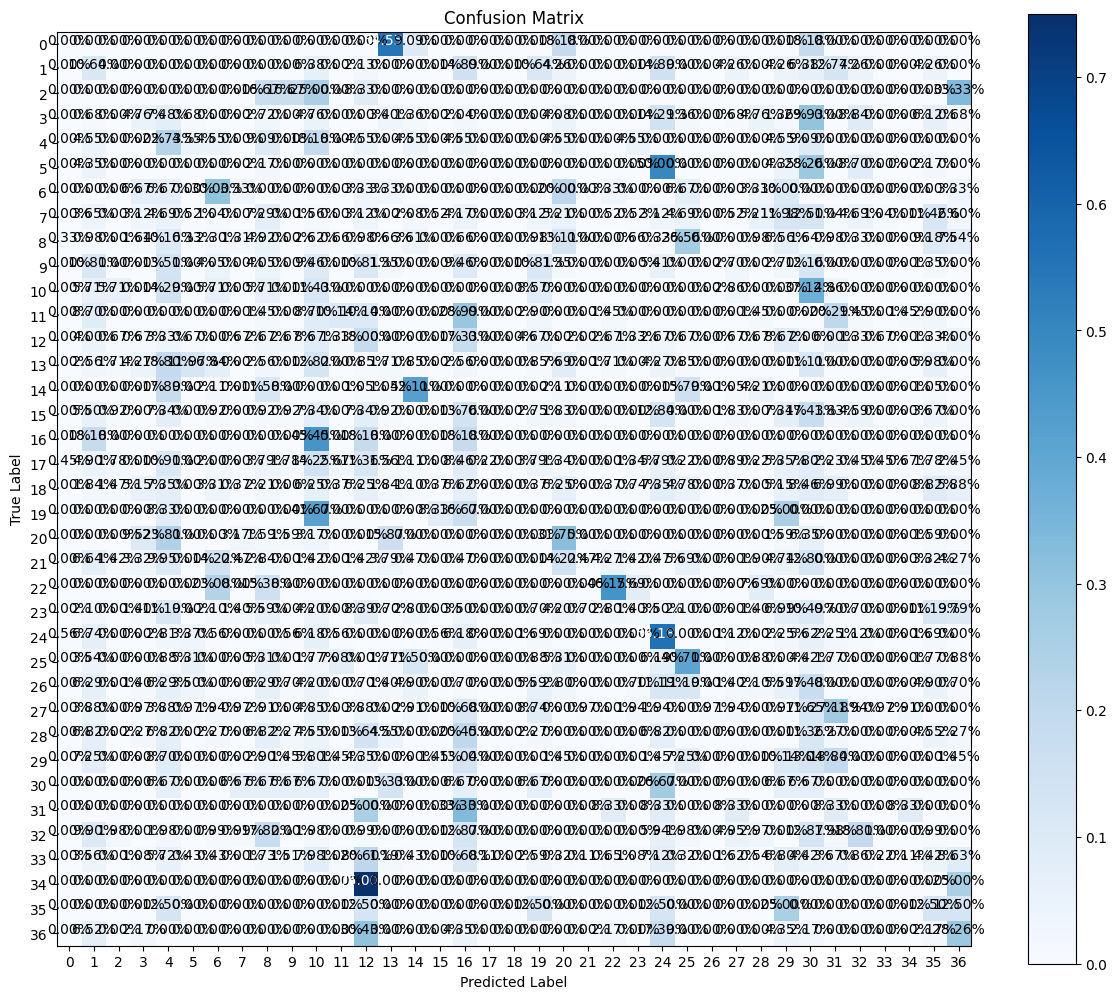

In [25]:
cm = confusion_matrix(y_test, np.argmax(preds, axis=1))

# Número de clases
num_classes = cm.shape[0]

# Normalizar la matriz de confusión
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Graficar
plt.figure(figsize=(12, 10))  # Opcional, para ajustar el tamaño de la figura
plt.imshow(cm_normalized, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(num_classes)
plt.xticks(tick_marks, range(num_classes), rotation=0)
plt.yticks(tick_marks, range(num_classes))

# Anotar la matriz
for i, j in itertools.product(range(cm_normalized.shape[0]), range(cm_normalized.shape[1])):
    plt.text(j, i, f"{cm_normalized[i, j]:.2%}",
            horizontalalignment="center",
            color="white" if cm_normalized[i, j] > 0.5 else "black")

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# Guardar la figura en formato PDF
plt.savefig('confusion_matrix.pdf', format='pdf')
plt.show()

In [26]:
accuracy_score(y_test, np.argmax(preds, axis=1))

0.07844474761255116

In [27]:
#codificar las etiquetas
y_test_labels = le.inverse_transform(y_test)
y_pred_labels = le.inverse_transform(np.argmax(preds, axis=1))

In [28]:
print(classification_report(y_test_labels, y_pred_labels))

                              precision    recall  f1-score   support

Campylorhynchus albobrunneus       0.00      0.00      0.00        11
     Campylorhynchus griseus       0.03      0.11      0.04        47
    Campylorhynchus nuchalis       0.00      0.00      0.00        12
    Campylorhynchus turdinus       0.10      0.05      0.06       147
     Campylorhynchus zonatus       0.02      0.23      0.03        22
        Cantorchilus griseus       0.00      0.00      0.00        46
     Cantorchilus leucopogon       0.09      0.30      0.14        30
       Cantorchilus leucotis       0.00      0.00      0.00       192
  Cantorchilus nigricapillus       0.09      0.05      0.06       305
     Cinnycerthia olivascens       0.00      0.00      0.00        74
        Cinnycerthia unirufa       0.01      0.11      0.02        35
       Cistothorus apolinari       0.16      0.10      0.12        69
       Cistothorus platensis       0.07      0.18      0.10       150
           Cyphorhi